# Exercise 4

## 1 Constructing the Matrix

In [7]:
import numpy as np
import scipy
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr

def construct_X(M, alphas, Np=None):
    if Np is None:
        Np = int(np.sqrt(2) * M)

        if Np % 2 == 0:
            Np += 1

    alphas = np.asarray(alphas, dtype=float)

    D = M * M
    No = len(alphas)
    N = Np * No

    # Pixelcoordinates centered at (0, 0)
    coordinates = np.arange(M) - (M - 1) / 2
    a, b = np.meshgrid(coordinates, coordinates)

    # Form (2, D)
    C = np.vstack((a.ravel(), b.ravel()))

    pixel_indices = np.arange(D)

    all_rows = []
    all_columns = []
    all_weights = []

    sensor_center = (Np - 1) / 2

    for angle_index, alpha_deg in enumerate(alphas):
        alpha = np.deg2rad(alpha_deg)

        #correct convention cos, -sin
        n = np.array([np.cos(alpha), -np.sin(alpha)])

        # Sensorpositions for all Pixels
        p = n @ C + sensor_center

        left = np.floor(p).astype(int)
        right = left + 1

        fraction = p - left
        w_left = 1.0 - fraction
        w_right = fraction

        valid_left = (left >= 0) & (left < Np) & (w_left > 0)
        valid_right = (right >= 0) & (right < Np) & (w_right > 0)

        all_rows.append(left[valid_left] + angle_index * Np)
        all_columns.append(pixel_indices[valid_left])
        all_weights.append(w_left[valid_left])

        all_rows.append(right[valid_right] + angle_index * Np)
        all_columns.append(pixel_indices[valid_right])
        all_weights.append(w_right[valid_right])

    i_indices = np.concatenate(all_rows)
    j_indices = np.concatenate(all_columns)
    weights = np.concatenate(all_weights).astype(np.float32)

    X = coo_matrix(
        (weights, (i_indices, j_indices)),
        shape=(N, D),
        dtype=np.float32
    )

    return X

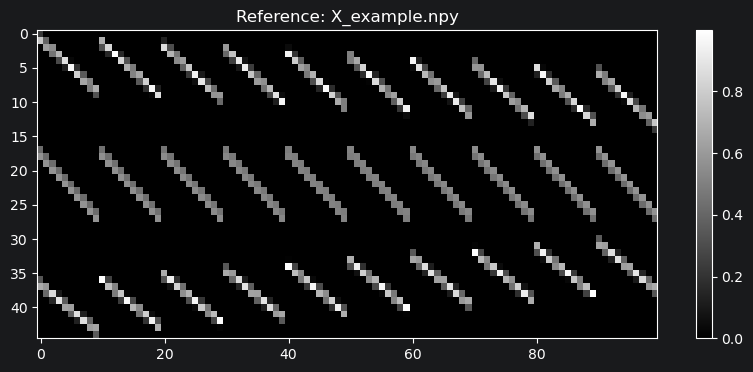

In [2]:
import matplotlib.pyplot as plt

X_ref = np.load("hs_tomography/X_example.npy")

def show_matrix(X, title):
    if hasattr(X, "toarray"):
        X = X.toarray()
    plt.figure(figsize=(10, 4))
    plt.imshow(X, cmap="gray", aspect="auto")
    plt.title(title)
    plt.colorbar()
    plt.show()

show_matrix(X_ref, "Reference: X_example.npy")

### Visulaization of different Orientation

![result.png](./result.png)


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>convention</th>
      <th>max_abs_diff</th>
      <th>sum_abs_diff</th>
      <th>mean_abs_diff</th>
      <th>frobenius_norm</th>
      <th>matches_reference</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>2</th>
      <td>[cos(alpha), -sin(alpha)]</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>True</td>
    </tr>
    <tr>
      <th>0</th>
      <td>[-cos(alpha), sin(alpha)]</td>
      <td>0.997805</td>
      <td>529.595032</td>
      <td>0.117688</td>
      <td>17.990295</td>
      <td>False</td>
    </tr>
    <tr>
      <th>1</th>
      <td>[-cos(alpha), -sin(alpha)]</td>
      <td>0.997805</td>
      <td>552.166809</td>
      <td>0.122704</td>
      <td>18.275146</td>
      <td>False</td>
    </tr>
    <tr>
      <th>3</th>
      <td>[cos(alpha), sin(alpha)]</td>
      <td>0.997805</td>
      <td>377.515320</td>
      <td>0.083892</td>
      <td>15.314450</td>
      <td>False</td>
    </tr>
  </tbody>
</table>
</div>

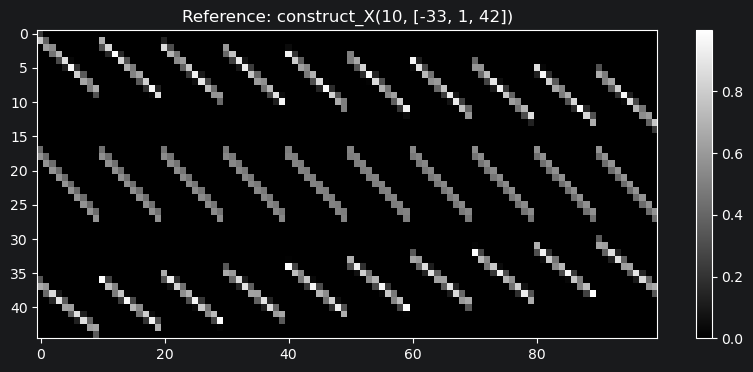

True

In [3]:
X_test = construct_X(10, [-33, 1, 42]) # Test created function

show_matrix(X_test, "Reference: construct_X(10, [-33, 1, 42])")

### Compare against figure 2
comparison = np.allclose(X_ref, X_test.toarray())
comparison  # Constructed X is equivalent to the reference example

## 2 Recovering the Image

In [34]:
# Smaller one
a77 = np.load("hs_tomography/alphas_77.npy")
y77 = np.load("hs_tomography/y_77.npy")
X_small = construct_X(77, a77)

# Larger one
a195 = np.load("hs_tomography/alphas_195.npy")
y195 = np.load("hs_tomography/y_195.npy")
X_large = construct_X(195, a195)

# Exactly how many non-zero entries does X have? Use scipy's tools to and out and report the sparsity of X.
X_small_nnz = X_small.nnz
X_small_sparsity = (np.prod(X_small.shape) - X_small_nnz) / np.prod(X_small.shape)
print(f"X_small has {X_small_nnz} non-zero entries with {X_small_sparsity:.3f} sparsity")

X_large_nnz = X_large.nnz
X_large_sparsity = (np.prod(X_large.shape) - X_large_nnz) / np.prod(X_large.shape)
print(f"X_large has {X_large_nnz} non-zero entries with {X_large_sparsity:.3f} sparsity")

# Original image reconstruction
# X_77_reference = np.load("hs_tomography/X_77.npy", allow_pickle=True)
# X_77_reference = scipy.sparse.csc_matrix(X_77_reference.all())

small_image = lsqr(X_small, y77, atol=1e-05, btol = 1e-05)
large_image = lsqr(X_large, y195, atol=1e-05, btol = 1e-05)
# reference_image = lsqr(X_77_reference, y77, atol=1e-05, btol = 1e-05) # Dimension mismatch???

X_small has 1066978 non-zero entries with 0.982 sparsity
X_large has 13535933 non-zero entries with 0.993 sparsity


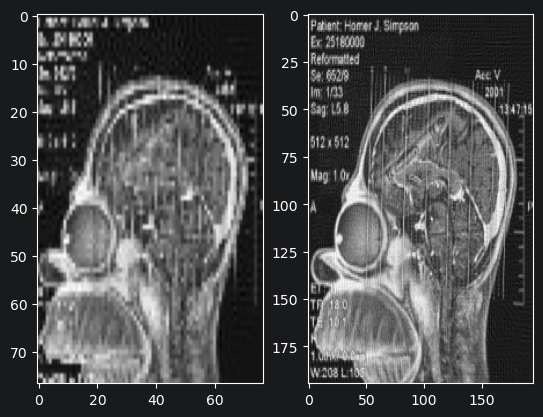

In [35]:
# Plot small and large images
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(small_image[0].reshape(77,77), cmap="gray", aspect="auto")
ax2.imshow(large_image[0].reshape(195,195), cmap="gray", aspect="auto")
plt.show()

Diagnosis: H.S.'s headache is caused by having a crayon inside his brain. A treatment would be to not eat crayons or lodge them inside his cranial cavity lol.